 # <center> Problem Set 3 (Molecular Properties) <center>
<center> Spring 2025 <center>
<center> 3.C01/3.C51, 7.C01/7.C51, 10.C01/10.C51, 20.C01/20.C51 <center>
<center> Due: Wednesday, April 23, 2025 at 3:00 PM ET. <center>

<b>Name:</b>

<b>Kerberos ID:</b>

Before starting, make sure to **request a GPU**! For this PSET, a **T4 GPU** should be sufficient to complete all problems.

### Download required data

In [ ]:
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps3-nonbio/data/solubility.csv
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps3-nonbio/data/bace.csv

In [ ]:
#install RDKit
!pip install rdkit
!pip install tqdm

import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors,Crippen
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import itertools
from tqdm import tqdm

import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, r2_score
from sklearn.utils import shuffle

matplotlib.rcParams.update({'font.size': 15})
matplotlib.rc('lines', linewidth=3, color='g')
matplotlib.rcParams['axes.linewidth'] = 2.0
matplotlib.rcParams['axes.linewidth'] = 2.0
matplotlib.rcParams["xtick.major.size"] = 6
matplotlib.rcParams["ytick.major.size"] = 6
matplotlib.rcParams["ytick.major.width"] = 2
matplotlib.rcParams["xtick.major.width"] = 2
matplotlib.rcParams['text.usetex'] = False

In Problem Set 3, you'll explore building Graph Neural Network architectures for molecular properties, with the following objectives:
* Learning how to visualize and process molecules with `RDKit`
* Building graphs from your molecules, then packaging their information in a convenient manner for modern GNN architectures
* How to implement a (2D) GNN
* Understanding the limitations of 2D GNNs for trying to predict 3D properties

# <center>Problem 1: Predicting Solubility with a 2D Graph Convolutional Net (GCN) </center>

### 1.1 (5 points) Load and visualize some molecules with `RDKit`

RDKit example

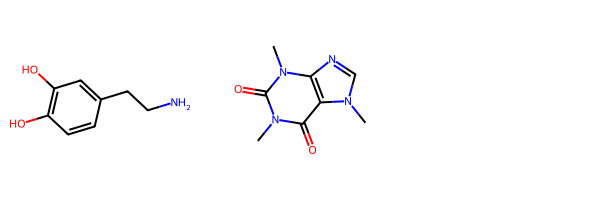

In [47]:
dopamine_mol = Chem.MolFromSmiles("C1=CC(=C(C=C1CCN)O)O") # Dopamine
caffeine_mol = Chem.MolFromSmiles("CN1C=NC2=C1C(=O)N(C(=O)N2C)C") # Caffeine
# Arrange molecules in a grid image
Draw.MolsToGridImage([dopamine_mol, caffeine_mol])

Use RDKit to visualize 4 of your favorite molecules.

In [ ]:
################ Code #################


################ Code #################

## 1.2 (5 points) Collect atom and bond information for a sample molecule

With RDKit, we can collect lots of atom-level features conveniently. These might include the atomic number, fundamentally, but it can also include hybridization, the formal charge of atoms, degree of atoms, hydrogen count, and aromaticity. Let's explore how to collect these features using RDKit, so that you can collect these features for all the molecules.

Your goal in this problem will be to collect the following atomic features for each atom in each molecule you process (notice how each of these vary in type):
1. Atomic number (discrete)
2. Hybridization: sp, sp2, sp3, sp3d, ... (categorical) -- as these are string types, [rdkit offers an OHE](https://www.rdkit.org/docs/source/rdkit.Chem.rdchem.html#rdkit.Chem.rdchem.HybridizationType) of the various states with `.real`
3. Aromaticity (binary)
4. attached Hydrogen count (discrete)
5. degree (discrete)
6. Formal charge (discrete)

Here is an example of some of the handy featurization available in RDKit:


In [ ]:
# first, a visualization of atomic ordering, so you know which indices correspond to which atoms.
deprot_dopamine = Chem.MolFromSmiles('NCCC1=CC(O)=C([O-])C=C1')

from rdkit.Chem import Draw
for atom in deprot_dopamine.GetAtoms():
    atom.SetProp('atomNote',str(atom.GetIdx() + 1)) # notice I have changed this to 1-indexing for easier visual matching
display(Draw.MolToImage(deprot_dopamine, size=(300,300)))


print("Num atoms", len(deprot_dopamine.GetAtoms()))
# you can adapt this code by changing `str(atom.GetIdx())` to str(atom.{feature call})`
# to visualize the feature values by atom for a feature value of interest. try it out!

# calculating atomic number:
print("Atomic number", [atom.GetAtomicNum() for atom in deprot_dopamine.GetAtoms()])

# hybridization:
print("Hybridization", [str(atom.GetHybridization()) for atom in deprot_dopamine.GetAtoms()])
# RDKit offers an OHE of the hybridization for us
print("Hybridization, OHE", [atom.GetHybridization().real for atom in deprot_dopamine.GetAtoms()])

# aromaticity:
print("Aromaticity", [atom.GetIsAromatic() for atom in deprot_dopamine.GetAtoms()])

# number of attached hydrogens:
print("# of attached hydrogens", [atom.GetTotalNumHs() for atom in deprot_dopamine.GetAtoms()])

# degree (# of bonds atom is involved in):
print("Degree of each atom", [atom.GetDegree() for atom in deprot_dopamine.GetAtoms()])

# formal charge:
print("Formal charge", [atom.GetFormalCharge() for atom in deprot_dopamine.GetAtoms()])

Task 1: Write a `smiles2features` function that takes in a SMILES and collects the above features. For one molecule, your code should output a 2D array of atom features and a 2D array of edges.

For the 2D array of atom features, make sure the first dimension is the number of atoms and the second dimension is the number of features; this is the reference dimensioning that will be used throughout the pset, so it's important this is consistent!

You can obtain the edge pairs from a Mol object by converting its connectivity into an adjacency matrix (do not tweak the call we give you) and you will need to find the indices of the nonzero entries of that matrix. Return your edge pairs as a (2, n_edges) array.

Hint 1: what should be the length of the final feature set of the atoms, considering any necessary OHE?

In [50]:
def smiles2features(smiles):
    '''
    Transform smiles into a list of atomic numbers and an edge array

    Args:
        smiles (str): SMILES strings

    Returns:
        atom_features (np.array): 2D array of atom features. The first dimension should be # of atoms, second dimension should be # of features.
        edge_pairs (np.array): 2D array of edge pairs
    '''
    mol = Chem.MolFromSmiles(smiles)
    adj_mat = np.array(np.stack(Chem.GetAdjacencyMatrix(mol)))
    ################ Code #################




    ################ Code #################
    return atom_features, edge_pairs

## Part 1.3: (5 points) Process all samples in the dataset with `smiles2features`

Task 1: Read in the DataFrame, shuffle its rows, and store its properties as lists.

In [51]:
df = pd.read_csv("solubility.csv")
df = shuffle(df).reset_index()

# torch.LongTensor refers to tensors with numerical int64 types.

AtomicFeatures_list = [] #list of torch.LongTensor
Edge_list = [] #list of torch.LongTensor
Natom_list = [] #list of int
y_list = [] #list of torch.FloatTensor

################ Code #################





################ Code #################

Task 2: Based on the processing of the code (you may need to play around and visualize some molecules), answer these two questions (two sentences for each should be sufficient):   
1. Is there any redundancy amongst the features we have provided? Phrased another way, is it possible to compute one of the atomic features from a combination of the others? (The answer may be no; ultimately, we're looking to see that you have made some interpretation of the features).   
2. Does the `Natom_list` object keep counts that include the # of hydrogens? Why/why not?
3. What information about bonds have we retained, in `Edge_list`? Do we have any information about bond order? Might there be any atomic features that might give us some clues about bond order?

Some helpful utilities for answering questions:
* if you have a molecule defined by `mol = Chem.MolFromSmiles(smi)`, you can view how/where hydrogens are on the molecule with `Chem.AddHs(mol)`.

A: Your Answer Here

## Part 1.4 (5 points) Construct molecular graph `Datasets` and `DataLoaders`

### Creating `Datasets`

A GraphDataset class for you to store graphs in PyTorch.




In [52]:
class GraphDataset(torch.utils.data.Dataset):
    def __init__(self,
                 AtomicFeatures_list,  # list of torch.Tensor, each [n_atoms, feature_dim]
                 Edge_list,             # list of torch.LongTensor
                 Natom_list,            # list of int
                 y_list):               # list of torch.FloatTensor
        '''
        GraphDataset object

        Args:
            AtomicFeatures_list (list of torch.Tensor): Atom feature matrices per graph.
            Edge_list (list of torch.LongTensor): Edge lists for each graph.
            Natom_list (list of int): Number of atoms in each graph.
            y_list (list of torch.FloatTensor): Graph-level target properties.
        '''
        self.AtomicFeatures_list = AtomicFeatures_list
        self.Edge_list = Edge_list
        self.Natom_list = Natom_list
        self.y_list = y_list

    def __len__(self):
        return len(self.Natom_list)

    def __getitem__(self, idx):
        # Directly return the stored tensors and values
        AtomicFeatures = self.AtomicFeatures_list[idx]
        Edge = self.Edge_list[idx]
        Natom = self.Natom_list[idx]
        y = self.y_list[idx]
        return AtomicFeatures, Edge, Natom, y

Task 1: Split your dataset into train, validation, and test splits (70% training, 10% validation, and 20% testing data); then, define the GraphDataset class for each.

Hint: Confirm that the lengths of each Dataset match up with the above percentages.

In [53]:
################ Code #################

train_dataset = None # fill this in
val_dataset = None # fill this in
test_dataset = None # fill this in

################ Code #################

### Creating `DataLoaders`

To properly batch different graphs, we will need to define a graph collation function to batch multiple graphs into one batch.

In [54]:
def collate_graphs(batch):
    '''
    Batch multiple graphs into one batched graph.

    Args:
        batch (list of tuples): Each tuple is (Atomic_features, Edge, N, y)
            where Atomic_features is a tensor of shape [n_atoms, feature_dim],
            Edge is a tensor of shape [2, n_edges],
            N is the number of atoms in the graph,
            and y is the target property.

    Returns:
        tuple: Batched Atomic_features, Edge, N (list), and y.
    '''
    AtomicFeatures_batch = []
    Edge_batch = []
    Natom_batch = []
    y_batch = []

    # Compute cumulative atom counts to shift edge indices
    cumulative_atoms = np.cumsum([0] + [b[2] for b in batch])[:-1]

    for i, (features, edge, N, y) in enumerate(batch):
        index_shift = cumulative_atoms[i]
        edge = edge + index_shift  # Shift edge indices appropriately
        AtomicFeatures_batch.append(features)
        Edge_batch.append(edge)
        Natom_batch.append(N)
        y_batch.append(y)

    # Concatenate the feature and edge tensors
    AtomicFeatures_batch = torch.cat(AtomicFeatures_batch, dim=0)
    Edge_batch = torch.cat(Edge_batch, dim=1)
    y_batch = torch.cat(y_batch, dim=0)

    return AtomicFeatures_batch, Edge_batch, Natom_batch, y_batch

Here is an example use of `collate_graph`; make sure you understand how the collation is performed!

In [ ]:
# Example Graph 1 definition, involving 3 atoms and 4 bonds.
# Each atom is represented by a feature vector, e.g. [atomic number, num_hydrogens]
AtomicFeatures1 = torch.tensor([[6, 0],
                                [6, 1],
                                [7, 2]], dtype=torch.float)  # shape: [3, 2]
Edge1 = torch.tensor([[0, 2, 2, 1],
                      [2, 0, 1, 2]], dtype=torch.long)
Natom1 = 3
y1 = torch.tensor([74.18], dtype=torch.float)

# Example Graph 2 definition, involving 4 atoms and 5 bonds.
AtomicFeatures2 = torch.tensor([[6, 1],
                                [6, 3],
                                [8, 2],
                                [6, 1]], dtype=torch.float)  # shape: [4, 2]
Edge2 = torch.tensor([[0, 2, 2, 1, 3],
                    [2, 0, 1, 2, 2]], dtype=torch.long)  # shape: [2, 5]
Natom2 = 4
y2 = torch.tensor([64.32], dtype=torch.float)

graph1 = (AtomicFeatures1, Edge1, Natom1, y1)
graph2 = (AtomicFeatures2, Edge2, Natom2, y2)

# Batch the two graphs using collate_graphs
batched_features, batched_edge, batched_Natom, batched_y = collate_graphs((graph1, graph2))
print(batched_features)
print(batched_edge)
print(batched_Natom)
print(batched_y)

Task 2: Define the train, validation, and test DataLoaders with the above collation function. Set the batch size to 512; shuffle to True only for the train loader; and set `num_workers` to 2.

In [56]:
################ Code #################

train_loader = None # fill in

val_loader = None # fill in

test_loader = None # fill in

################ Code #################

## Overview of `scatter_add` and `torch.split()`

First, we define one of the convolutions, `scatter_add`; this takes in a list of indices and source values that are being passed into an output tensor by summing the source values at positions specified by these indices along a given dimension.

In [57]:
def scatter_add(src, index, dim_size, dim=-1, fill_value=0):

    '''
    Sums all values from the src tensor into out at the indices specified in the index
    tensor along a given axis dim.
    '''

    index_size = list(itertools.repeat(1, src.dim()))
    index_size[dim] = src.size(dim)
    index = index.view(index_size).expand_as(src)

    dim = range(src.dim())[dim]
    out_size = list(src.size())
    out_size[dim] = dim_size

    out = src.new_full(out_size, fill_value)

    return out.scatter_add_(dim, index, src)

Here is an example usage of scatter_add().

In [58]:
# Say you have a graph with 4 nodes, and there are an edge list that describes their connectivities (5 edges).

Edge = torch.LongTensor([[0, 0, 1, 3, 2], # index for i
                         [1, 2, 2, 0, 3]]) # index for j

# It means that the 0th node is connected to 1st node and the 2nd node; the 1st node is connected to the 2nd node.
# For now, let us assume the connections are directed, i.e. 0th node is connected the 1st node, but the 1st node is not connected to the 0th node.
# We want pass connection messages from the nodes in the first row to the nodes in the second row in Edge.

# And for each **edge**, we have an message we wanto broadcast from i to j.
message_i2j = torch.Tensor([1000., 100., 10., 1., 20.])

# We can use scatter_add() function to aggregate these pairwise messages onto each node.

node_message = scatter_add(src=message_i2j, # message array for all the directed edge
            index=Edge[1], # index to all the jth node to which you want to pass your message
            dim=0,         # feature dimension you want to sum over
            dim_size=4     # there are 4 nodes
            )

print(node_message)

# Now you can look at your results, you can see the messages are assigned from message_i2j to all the jth nodes you specified

# see a visual representation here: "https://pytorch-scatter.readthedocs.io/en/1.3.0/functions/add.html"

tensor([   1., 1000.,  110.,   20.])


In [59]:
# If you want your graph to be undirected, i.e. the ith node is connected to the jth node and vice versa, you can perform the summation in both direction like this
# The only difference between the calls are the "sink"/destination vertices specified in `index`, with both being used to perform bidirectional message passing on the same edges.
node_message = scatter_add(src=message_i2j, index=Edge[1], dim=0, dim_size=4) +  scatter_add(src=message_i2j, index=Edge[0], dim=0, dim_size=4)

print(node_message)

tensor([1101., 1010.,  130.,   21.])


In addition to `scatter_add()`, we also need to use `torch.split()` to unbatch graphs based on the indexing we've been storing in `Natom_batch`; here is some example usage:




In [60]:
# suppose you have batched two graphs, with natoms_1 = 2 and natoms_2 = 3, and with two different atomic features collected.
# then, their collated atomic_feature matrix is (5, 2)
sample_tensor = torch.tensor([[6, 2],
                              [6, 3],
                              [5, 3],
                              [7, 1],
                              [6, 1]])
splits_idx = [2, 3] # list of integers
print("result of splitting: ", torch.split(sample_tensor, splits_idx) )

# you have two tensors with size (2,2) and (3,2) respectively
for idx, split in enumerate(torch.split(sample_tensor, splits_idx)):
    print(f"shape of tensor {idx}", split.shape)

# And you can sum the spllited array separately and stack (aka collate) them together
# Notice that the dimension must be specified properly to make sure you don't sum across multiple graphs accidentally!
# Here, we are summing over dimension 0 (over all atoms) and stacking on dimension 0 (so one entry per graph, rather than feature)
print( torch.stack([split.sum(0) for split in torch.split(sample_tensor, splits_idx)], dim=0) )

result of splitting:  (tensor([[6, 2],
        [6, 3]]), tensor([[5, 3],
        [7, 1],
        [6, 1]]))
shape of tensor 0 torch.Size([2, 2])
shape of tensor 1 torch.Size([3, 2])
tensor([[12,  5],
        [18,  5]])


## Part 1.5.grad (20 points, grad) Complete the definition of a GNN
Undergrad students, complete `1.5.undergrad` (next cell).

Complete the initialization and forward calls based on the description in the PDF.

**Task 1**: Complete the embedding layers in the initialization and use them properly in the forward call. You'll need to make one nn.Embedding layer for each of the features; then in the initialization call, concatenate your embeddings and then feed that embedding to a linear layer that outputs a feature length of `n_embed`.

**Task 2**: Fill in the convolution code, following the math in the PDF and the layers provided already in the initialization function. The above walkthrough on scatter_add and torch.split() may be helpful in completing the code.

**Task 3**: Use the readout layer to produce a final per-node embedding of length 1; then, split them by nodes of a graph and sum over nodes of a graph to produce a single value per graph.

In [61]:
class GNN(torch.nn.Module):
    '''
    A GNN model
    '''
    def __init__(self, n_convs=3, n_embed=64):
        super(GNN, self).__init__()
        # We will need to embed _each_ feature using one-hot encoding.
        ohe_embeds = []

        # TODO: Define embedding layers for each of the features.
        # You will need one layer per feature,
        # Then one layer that goes from the sum of all the feature layers to n_embed.
        # (That means you will need to make 7 layers!)
        ################ Code #################







        ################ Code #################
        # Declare MLPs in a ModuleList
        self.convolutions = nn.ModuleList(
            [
                nn.ModuleDict({
                    'update_mlp': nn.Sequential(nn.Linear(n_embed, n_embed),
                                                nn.ReLU(),
                                                nn.Linear(n_embed, n_embed)),
                    'message_mlp': nn.Sequential(nn.Linear(n_embed, n_embed),
                                                 nn.ReLU(),
                                                 nn.Linear(n_embed, n_embed))
                })
                for _ in range(n_convs)
            ]
            )
        # Declare readout layers
        self.readout = nn.Sequential(nn.Linear(n_embed, n_embed), nn.ReLU(), nn.Linear(n_embed, 1))

    def forward(self, AtomicFeature, Edge, Natom):

        # TODO: parameterize the embeddings using each of the features, concat and embed in your first linear layer
        ################ Code #################


        ################ Code #################
        # TODO: compute the convolutions
        ################ Code #################


        ################ Code #################


        # TODO: Perform the readout layer and split by nodes, return a single value per graph. 
        ################ Code #################


        ################ Code #################
        return output

## Part 1.5.undergrad (10 points, undergrad) Define the first embedding layers of a GNN
Graduate students, do not complete this cell, only complete 1.5.grad (previous cell).

If you are an undergrad, you do not have to fill out the above implementation; instead, you will complete a simpler version of a PyTorch Geometric GNN that only requires you to complete the embedding layers required and do the readout.

**Task 1**: Complete the embedding layers in the initialization and use them properly in the forward call. You'll need to make one `nn.Embedding` layer for each of the features, as well as an linear layer; then in the forward call, concatenate your embeddings and then feed that embedding to the linear layer, which should output a feature length of `n_embed`.


**Task 2**: Use the readout layer to produce a final per-node embedding of length 1; then, split them by nodes of a graph and sum over nodes of a graph to produce a single value per graph.

In [ ]:
'''
!pip install torch_geometric
import torch_geometric

# Wrapper class around torch_geometric GCN to match expected inputs
class GNN(torch_geometric.nn.models.GCN):
    def __init__(self, n_convs=3, n_embed=64):
        # Instantiate GCN
        super(GNN, self).__init__(-1,n_embed,n_convs)

        # TODO: Define embedding layers for each of the features.
        # You will need one layer per feature,
        # Then one layer that goes from the sum of all the feature layers to n_embed.
        # (That means you will need to make 7 layers!)
        ################ Code #################



        ################ Code #################

        # Declare readout layers
        self.readout = nn.Sequential(nn.Linear(n_embed, n_embed), nn.ReLU(), nn.Linear(n_embed, 1))


    def forward(self, AtomicFeature, Edge, Natom):
        # TODO: parameterize the embeddings using each of the features, 
        # then concat and embed with your first linear layer
        ################ Code #################


        ################ Code #################
        h = super(GNN, self).forward(h,Edge)
        
        # TODO: Perform the readout layer and split by nodes, return a single value per graph. 
        ################ Code #################


        ################ Code #################
        return output
'''

## Part 1.6 (5 points, grad) Verify that your GNN preserves permutational invariance

Run this cell as is to show that your GNN respects permutational invariance.

In [ ]:
def permute_graph(z, a, perm):
    '''
        permute the order of nodes in a molecular graph

        Args:
            z(np.array): atomic number array
            a(np.array): edge index pairs

        Return:
            (np.array, np.array): permuted atomic number, and edge list
    '''

    z = np.array(z)
    perm = np.array(perm)
    assert len(perm) == len(z)

    z_perm = z[perm]
    a_perm = np.zeros(a.shape).astype(int)

    for i, edge in enumerate(a):
        for j in range(len(edge)):
            indices = np.where(perm == edge[j])[0]
            if indices.size > 0:
                a_perm[i, j] = indices[0]
    return z_perm, a_perm

# node input: this is (n_atoms, n_feats).
atom_feats_ex = np.array([
    [6, 0, 4, 2, 3, 0],
    [6, 0, 4, 1, 2, 0],
    [8, 0, 3, 0, 1, 0],
    [7, 0, 4, 0, 1, 0]
])
# edge input
edge_idx_ex = np.array([[0, 0, 1, 2, 3, 0], [1, 2, 0, 0, 0, 3]])

permutation = itertools.permutations([0, 1, 2, 3]) # reordering of indices of dim0 of atom_feats_ex.
device = 'cuda:0'
model = GNN(n_convs=4, n_embed=128).to(device)
model.eval()

for perm in permutation:
    z_perm, a_perm = permute_graph(atom_feats_ex, edge_idx_ex, perm)

    z = torch.LongTensor(z_perm).to(device)
    a = torch.LongTensor(a_perm).to(device)
    N = [z.shape[0]]

    output = model(z, a, N).item()

    print("model output: {:.5f} for perumutation: {}".format(output, perm))

## Part 1.7 (5 points) Train and test your GNN




A combined train/validation loop, with progress bar.

In [64]:
def loop(model, loader, epoch, evaluation=False):

    if evaluation:
        model.eval()
        mode = "eval"
    else:
        model.train()
        mode = 'train'
    batch_losses = []

    for data in loader:

        AtomicFeatures, Edge, Natom, y = data
        AtomicFeatures = AtomicFeatures.to(device)
        Edge = Edge.to(device)
        y = y.to(device)
        pred = model(AtomicFeatures, Edge, Natom)
        loss = (pred-y).pow(2).mean() # MSE loss

        if not evaluation:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        batch_losses.append(loss.item())
    return np.array(batch_losses).mean()

**Task 1**: Run this cell to train your model for 150 epochs (this should not take more than 2 minutes).

In [ ]:
from torch import optim

device = 'cuda:0'
model = GNN(n_convs=4, n_embed=64).to(device)
epochs = 150

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=50, verbose=True)

def update(progress_bar, train_loss, val_loss):
    progress_bar.set_postfix({"train_loss": train_loss, "val_loss": val_loss})

progress_bar = tqdm(range(epochs))

for epoch in progress_bar:
    train_loss = loop(model, train_loader, epoch)
    val_loss = loop(model, val_loader, epoch, evaluation=True)

    update(progress_bar, train_loss, val_loss)

A helper function defined for evaluating the GNN on a given DataLoader:

In [66]:
def evaluate(model, dataloader, device):

    '''
    A function to return the predicted solubility (for evaluation).

    Args:
        model (torch.nn.Module): your sequence classifier
        dataloader (torch.utils.data.Dataloader): DataLoader object for the train data
        device (str): Your device

    Returns:
        (np.array, np.array): true values, predicted values
    '''

    y_pred_list = []
    y_list = []

    with torch.no_grad():
        model.eval()
        for batch in dataloader:

            AtomicFeatures, Edge, Natom, y = batch
            AtomicFeatures = AtomicFeatures.to(device)
            Edge = Edge.to(device)
            y = y.to(device)
            y_pred = model(AtomicFeatures, Edge, Natom)

            y_pred_list+=y_pred.detach().cpu().numpy().tolist()
            y_list+=y.detach().cpu().numpy().tolist()

    return np.array(y_list), np.array(y_pred_list)

**Task 2**: Calculate train and test R^2 and generate a scatter plot comparing true solubility to predicted solubility for train and test data (feel free to utilize your code from a previous pset).

In [ ]:
################ Code #################


# include these after your plt calls to ensure the axes have the same ranges
plt.xlim(-11,4)
plt.ylim(-11,4)

################ Code #################

print("The mean train R^2 is {:.2f}".format(train_r2))
print("The mean test R^2 is {:.2f}".format(test_r2))


## Part 1.8 (5 points) How do "identical" molecules compare?

Now that your GNN model can predict molecular solubilities, let's apply it to a pair of closely related molecules. The second molecule is a deprotonated version of the first, but otherwise have identical molecular connectivity. These subtle differences in their protonation states can significantly affect the intermolecular interactions with solvents like water. Solubility is sensitive to such changes, as variations in protonation influence how these molecules interact with the surrounding solvent environment.

In [ ]:
# look at these two molecules:
from rdkit.Chem import AllChem, Draw
from rdkit import Chem

smi1 = "CC1=C(C)C=C(C=C1)C(O)=O"
smi2 = "Cc1ccc(cc1C)C([O-])=O"
mol1 = Chem.MolFromSmiles(smi1)
mol2 = Chem.MolFromSmiles(smi2)

# Generate a depiction for mol2 that matches mol1's 2D structure. Use these same mol objects later for ease :) 
AllChem.Compute2DCoords(mol1)
AllChem.GenerateDepictionMatching2DStructure(mol2, mol1)
display(Draw.MolsToGridImage([mol1,mol2]))

# find their entries in the df:
display(df[df.SMILES.isin([smi1, smi2])])

**Task 1**: By visual inspection of these graphs, which of the atomic features that you encode in Part 1.2 would you expect to differ? What atomic features will remain the same? And, which molecule is recorded to be more soluble? (Bonus: can you explain why that molecule should be more soluble in terms of first-principles chemistry?)

A: Your Answer Here

**Task 2:** Process these SMILES into atom, edge, and atom count arrays the same way you did in 1.2, and pass these to your model to predict their solubility values. What happens? Is this expected? Explain why/why not.

In [ ]:
################ Code #################





################ Code #################

A: Your answer here.

## Part 1.9 (10 points, grad) Obtain and compare node-level embeddings of these molecules

Using the above molecules, let's dig a little deeper into the predictions from the model.

Recall that we perform a final aggregation layer and summation over all nodes after all message-passing convolutions are done to obtain a final scalar molecular-level value. However, the final atom-level embeddings/activations can be useful to garner some insights on which atoms contribute the most information to the solubility scores.

To do so, we can design a "hook", which essentially lets you grab information that comes from any intermediate _layer_ of the forward call before the final output. Since each intermediate layer in our GNN (after the initial concatenation of feature-specific embeddings) outputs an embedding per-atom, either of n_embed or 1, we can choose to look at the embeddings from any of these steps. For this problem, though, we'll keep things simple and look at the final per-atom embedding, which should be of width 1.

Task: Generate node-level embeddings for the two molecules using the hook functionality (see PDF for help, or this helpful [guide](https://medium.com/the-dl/how-to-use-pytorch-hooks-5041d777f904) for more discussion) from the last layer, which should have an embedding width of 1 (i.e, each atom has one feature value associated with it, and your node embeddings should be dimension (11,1)). Analyze differences in the embeddings, making sure to match up comparisons based on the original atom indices. What differences do you notice? How do these individual values relate to the differences in the final solubility scores?


In [ ]:
################ Code #################

# You'll need to use a variable you make global to be referenced by your hook function
node_embeds = None






node_embeds_1 = None # fill in
node_embeds_2 = None # fill in

################ Code #################

# tada we have node-level embeddings :)
# Let's visualize them for convenience

# annotate smi1, smi2 with node_embeds_1, node_embeds_2
for atom in mol1.GetAtoms():
    atom.SetProp("atomNote", str(np.round(node_embeds_1[atom.GetIdx()].item(), 3)))
for atom in mol2.GetAtoms():
    atom.SetProp("atomNote", str(np.round(node_embeds_2[atom.GetIdx()].item(), 3)))

Draw.MolsToGridImage([mol1, mol2], subImgSize=(400,400))

A: Your answer here

# Problem 2: Using the same GNN architecture to predict $IC_{50}$

## Part 2.1: (10 points) Explore the data distribution in the dataset

As mentioned in the background, molecular conformation and thus stereochemistry can influence the binding affinity and thereby $IC_{50}$ considerably. An unfavorable conformation can break important protein-ligand interactions. To get an idea of this property, let's view what kinds of stereochemistry are present in the data.


Task 1: Load the dataset and perform some exploratory data analysis.

1. What is the mean and variance of IC50 scores?
2. How many molecules with stereochemistry do we have in the dataset?  
    there are (at least) two approaches of finding stereochemistry:    
   * "Roundtrip" the molecule by making a mol from the original SMILES, then making two SMILES outputs: one that is an isomeric SMILES and a non-isomeric SMILES (i.e., one that retains any present chiral information), and compare the two output SMILES strings. If they are the same, the molecule didn't have any recorded stereochemistry. Pass `isomericSmiles=True` and `isomericSmiles=False` to the `Chem.MolToSmiles()` function to get the two SMILES strings for this. (use this option)     
   * iterating over a molecule's `bond`s with `mol.GetBonds()` and checking if any bonds have a stereochemistry other than `Chem.BondStereo.STEREONONE` with `bond.GetStereo()`
4. How many molecules _could_ have nontrivial stereochemistry recorded, but don't actually have any information recorded?
   * To solve this problem, you can find the number of chiral centers, i.e. atomic centers where nontrivial stereochemistry can be labeled, with `Chem.FindMolChiralCenters(mol, includeUnassigned=True)`. Then compute how many molecules have chiral centers but do not have stereochemistry tracked.

In [ ]:
df_ic50 = pd.read_csv("bace.csv")
df_ic50 = shuffle(df_ic50).reset_index()
print(f"There are {len(df_ic50)} total molecules")

################ Code #################
# Your code for Question 1:

ic50_mean = None
ic50_var = None

print("The mean IC50 is {:.2f}".format(ic50_mean))
print("The variance of IC50 is {:.2f}".format(ic50_var))

# Your code for Question 2:

has_stereo = None
print("There are {} molecules with stereochemistry".format(has_stereo))

# Your code for Question 3:

missing_possible_stereo = None
print("There are {} molecules with chiral centers but missing recorded stereochemistry".format(missing_possible_stereo))


################ Code #################

## Part 2.2: (5 points) Process the data into feature lists
Your code should reuse much of the processing from Problem 1, with two main changes:
* Make sure to use the `pIC50` column as the feature values.
* Use the train/validation/test splits as defined by the `Split` column in the dataset.

In [73]:
# As these lists are the same name as in Problem 1, take note that these will overwrite work in Problem 1, if you jump around cells
# torch.LongTensor refers to tensors with numerical int64 types.
Atomic_features_list = [] #list of torch.LongTensor
Edge_list = [] #list of torch.LongTensor
Natom_list = [] #list of int
y_list = [] #list of torch.FloatTensor

################ Code #################


################ Code #################

Split your dataset into train, validation, and test **according to the `Split` column in df** and define the GraphDataset class for each. Note that because we have a predefined split, we can't use `train_test_split`, so we have to resort to doing indexing, which we have set up for you. Also create the DataLoaders, this time with a batch size of 32 since we have fewer molecules in the dataset.

Make sure to use `shuffle=False` for the val & test `DataLoaders`.

In [74]:
################ Code #################
train_mask = (df_ic50["Split"] == None).values # Change
valid_mask = (df_ic50["Split"] == None).values # Change
test_mask = (df_ic50["Split"] == None).values # Change

# These will take the masks defined above to filter.
train_elems = [(atomic_feats, edge, natom, y) for (atomic_feats, edge, natom, y, mask) in zip(Atomic_features_list, Edge_list, Natom_list, y_list, train_mask) if mask]
AtomicFeats_train, Edge_train, Natom_train, y_train = zip(*train_elems)

valid_elems = [(atomic_feats, edge, natom, y) for (atomic_feats, edge, natom, y, mask) in zip(Atomic_features_list, Edge_list, Natom_list, y_list, valid_mask) if mask]
AtomicFeats_val, Edge_val, Natom_val, y_val = zip(*valid_elems)

test_elems = [(atomic_feats, edge, natom, y) for (atomic_feats, edge, natom, y, mask) in zip(Atomic_features_list, Edge_list, Natom_list, y_list, test_mask) if mask]
AtomicFeats_test, Edge_test, Natom_test, y_test = zip(*test_elems)

ic50_train_dataset = None # fill this in
ic50_val_dataset = None # fill this in
ic50_test_dataset = None # fill this in

################ Code #################

In [75]:
################ Code #################
ic50_train_loader = None # fill in
ic50_val_loader = None # fill in
ic50_test_loader = None # fill in
################ Code #################

## 2.3 (10 points) Train and evaluate your GNN's performance overall and by chiral center count

Task 1: Run this cell to train your model for 100 epochs (this should not take more than 2 minutes).

In [ ]:
from torch import optim

device = 'cuda:0'
ic50model = GNN(n_convs=4, n_embed=128).to(device)
epochs = 100

optimizer = optim.Adam(ic50model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=50, verbose=True)

def update(progress_bar, train_loss, val_loss):
    progress_bar.set_postfix({"train_loss": train_loss, "val_loss": val_loss})

progress_bar = tqdm(range(epochs))

for epoch in progress_bar:
    train_loss = loop(ic50model, ic50_train_loader, epoch)
    val_loss = loop(ic50model, ic50_val_loader, epoch, evaluation=True)

    update(progress_bar, train_loss, val_loss)

Task 2: Calculate train and test R^2 and generate a scatter plot comparing true pIC50 to predicted pIC50 for train and test data. Make sure you are using the new `ic50_{}_dataloader`s!

In [ ]:
################ Code #################


################ Code #################

print("The mean train R^2 is {:.2f}".format(train_r2))
print("The mean test R^2 is {:.2f}".format(test_r2))


Task 3: Stratify performance of the samples in your test model by number of chiral centers.

Make a seaborn boxplot that shows the distribution of absolute prediction errors for the test set, stratified by the number of chiral centers present in each molecule. This plot allows you to visually compare how prediction errors vary with the count of chiral centers in the molecules. Are there any trends?


In [ ]:
import seaborn as sns
################ Code #################


# Step 1: Here, we make a subset of the df_ic50 dataframe to use.
df_ic50_test = df_ic50.iloc[test_mask].copy()


# Step 2: Record the number of chiral centers for each SMILES. Store it in the column df_ic50_test["chiral_count"].
# your code to record the number of chiral centers, mirroring code from part 2.1


df_ic50_test["chiral_count"] = None # fill in

# Step 3: Compute the absolute error abs(true - predicted) from the y_true_arr and y_pred_arr
# Presuming we did not shuffle our test dataloader, the entries should readily line up with the indexing in the dataframe.
# Store the absolute error in df_ic50_test["absolute_error"].


df_ic50_test["absolute_error"] = None # fill in

# Step 4: Now you can visualize with column references from the dataframe directly, thanks to seaborn's convenience:
plt.figure(figsize=(6, 4))
sns.boxplot(x="chiral_count", y="absolute_error", data=df_ic50_test)
plt.title("Absolute Error Distribution by Chiral Centers")
plt.show()

################ Code #################

A: Your Answer Here

## Part 2.4 (10 points) How do two stereoisomers compare?

The dataset includes multiple sets of stereoisomers (molecules that have the same 2D connectivity but differ in their stereochemistry). You may have potentially stumbled upon these when exploring the data in 2.1.


Task 1: Amongst the subset of molecules that have recorded stereochemistry, find groups (of size **more than 1**) of molecules that share the same 2D connectivity. They do not need to be limited to a specific split of the dataset. How many such groups are there? Save this count to `num_stereogroups`, and the entries corresponding to these groups in `df_stereogroups`.

Hint: We can reformat the SMILES to be canonicalized and without any stereochemistry by using `Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)`.


Aside: the first 14 characters of an InChiKey, or the characters before the first `-`, represent 2D connectivity (up to tautomerization, meaning two tautomers of a molecule will be defined as having the same 2D connectivity under the default transforms). If two molecules have the same first 14 characters, they have the same 2D connectivity; however, this will match tautomers as well, so for this problem, use the reformatting SMILES strategy denoted above.

---



In [ ]:
################ Code #################
num_stereogroups = None # fill this in
df_stereogroups = None # fill this in
print("There are {} groups |G| > 1 of molecules with the same 2D connectivity".format(num_stereogroups))

################ Code #################

**Task 2:** For all of the entries that are found in these groups, process each of the _original_ SMILES (not the `clean_smiles`) into atom, edge, and atom count arrays the same way you did in 2.2, and pass these to your model to predict their IC50 values. Feel free to do this in a for loop, to make sure that you record the predicted pIC50s correctly for each molecule (we don't want you to get hung up on manual testing of your model!). Store each of these predicted pIC50 values back into your dataframe.


Important note: If your molecules happen to be tautomers of each other (i.e., have a migration of hydrogen atoms around the molecule), for the purposes of this problem, standardize them to be the same tautomer to remove protonation state as a confounding variable. You can do this by converting to and from Inchi, like so: `corr_mol = Chem.MolFromInchi(Chem.MolToInchi(orig_mol))`. Make sure that you do not inadvertently remove recorded stereochemistry.

In [ ]:
################ Code #################
# write code to predict the pIC50 with your model, `ic50model`, for each of the molecules that belong to one of the groups above.
# store these back into the dataframe. 



################ Code #################

**Task 3:** Now, compare your pIC50 values to the recorded pIC50 values. How do the predicted values compare to the true IC50 values? Pick one of the groups where you can demonstrate that the GNN has not properly learned chirality (i.e., predicts the same value when it shouldn't).


**Important note:** To simplify assumptions for this problem, select two molecules from the same group where both molecules have recorded, differing stereochemistry. Although a molecule without recorded stereochemistry may be present in the group, the most meaningful comparison will occur between two molecules that explicitly have documented stereochemical differences.

In [ ]:
################ Code #################
# you are welcome to manually inspect the DataFrame, 
# or write simple code to do comparison between pairs and recorded vs. predicted.





################ Code #################

Q: Describe the differences between the true and predicted IC50 values. What happened?

A: Your answer here

You've reached the end of the pset! Submit your completed work as a `.ipynb` to Gradescope [here](https://www.gradescope.com/courses/1011324/assignments/6083092/). If you had any AI-based assistance or worked with collaborators, please list this in the following cell.